## Auto Machine Learning
### Yilin Luo

## 1. Introduction

In today’s rapidly evolving financial landscape, accurately assessing the risk of loan default is critical for maintaining the profitability and stability of lending institutions. This assignment leverages a real-world dataset containing a diverse array of demographic, behavioral, and financial variables related to loan applicants, with the aim of developing a robust machine learning model to predict default risk. By combining comprehensive data preparation, advanced feature engineering, and automated machine learning (AutoML) techniques, we systematically evaluate and enhance the model’s ability to distinguish high-risk applicants. The analysis not only explores the predictive performance of various algorithms, but also examines the practical implications of model outputs for business profitability and risk mitigation, ultimately providing actionable insights for data-driven lending strategies.


## 2. Data Preparation and Feature engineering

In [61]:
#!pip install scikit-learn pandas numpy matplotlib seaborn plotly pycaret category_encoders h2o

In [62]:
# data
import pandas as pd
import numpy as np

# visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#import missingno as msno
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
#from wordcloud import WordCloud

from sklearn import datasets
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# styling
%matplotlib inline
sns.set_style('darkgrid')
mpl.rcParams['font.size'] = 12
mpl.rcParams['figure.facecolor'] = '#00000000'
mpl.rcParams['font.size'] = 12
mpl.rcParams['figure.facecolor'] = '#00000000'

import os 
#from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

### Load and Prepare Data

In [63]:
path = '/Users/yilin/Downloads'
data =  pd.read_csv(path + "/XYZloan_default_llm.csv")

In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  16000 non-null  int64  
 1   Unnamed: 0    16000 non-null  int64  
 2   AP001         16000 non-null  int64  
 3   AP002         16000 non-null  int64  
 4   AP003         16000 non-null  int64  
 5   AP006         16000 non-null  object 
 6   AP007         16000 non-null  int64  
 7   AP008         16000 non-null  int64  
 8   CR004         16000 non-null  int64  
 9   CR009         16000 non-null  int64  
 10  CR015         16000 non-null  int64  
 11  CR017         16000 non-null  int64  
 12  CR018         16000 non-null  int64  
 13  CR019         16000 non-null  int64  
 14  MB005         15441 non-null  float64
 15  MB007         16000 non-null  object 
 16  PA022         15918 non-null  float64
 17  PA023         15918 non-null  float64
 18  PA028         15918 non-nu

In [65]:
# assign new column name using variables dictionary
columns = {
    'AP001': 'YR_AGE',
    'AP002': 'CODE_GENDER',
    'AP003': 'CODE_EDUCATION',
    'AP006': 'OS_TYPE',
    'AP007': 'LEVEL_APPL_CITY',
    'AP008': 'FLAG_IP_CITY_NOT_APPL_CITY',
    'CR004': 'CNT_QUERY_TIME_LAST_1MON',
    'CR009': 'AMT_LOAN_TOTAL',
    'CR015': 'MONTH_CREDIT_CARD_MOB_MAX',
    'CR017': 'SCORE_DEBIT_CARD_TOTAL_AMT',
    'CR018': 'SCORE_DEBIT_CARD_UTILITY_AMT',
    'CR019': 'SCORE_SINGLE_DEBIT_CARD_LIMIT',
    'MB005': 'YR_PHONE_ACTIVE',
    'MB007': 'Application_Device',
    'PA022': 'DAYS_BTW_APP_AND_FIRST_COLLECTION_OR_HIGH_RISK_CALL',
    'PA023': 'DAYS_BTW_APP_AND_FIRST_COLLECTION_CALL',
    'PA028': 'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS',
    'PA029': 'AVG_LEN_COLLECTION_OR_HIGH_RISK_INBOUND_CALLS',
    'PA031': 'AVG_LEN_COLLECTION_CALLS',
    'TD001': 'TD_CNT_QUERY_LAST_7Day_P2P',
    'TD002': 'TD_CNT_QUERY_LAST_7Day_SMALL_LOAN',
    'TD003': 'TD_CNT_QUERY_LAST_7Day_BANK',
    'TD004': 'TD_CNT_QUERY_LAST_7Day_OTHER',
    'TD005': 'TD_CNT_QUERY_LAST_1MON_P2P',
    'TD006': 'TD_CNT_QUERY_LAST_1MON_SMALL_LOAN',
    'TD007': 'TD_CNT_QUERY_LAST_1MON_BANK',
    'TD008': 'TD_CNT_QUERY_LAST_1MON_OTHER',
    'TD009': 'TD_CNT_QUERY_LAST_3MON_P2P',
    'TD010': 'TD_CNT_QUERY_LAST_3MON_SMALL_LOAN',
    'TD011': 'TD_CNT_QUERY_LAST_3MON_BANK',
    'TD012': 'TD_CNT_QUERY_LAST_3MON_OTHER',
    'TD013': 'TD_CNT_QUERY_LAST_6MON_P2P',
    'TD014': 'TD_CNT_QUERY_LAST_6MON_SMALL_LOAN',
    'TD015': 'TD_CNT_QUERY_LAST_6MON_BANK',
    'TD016': 'TD_CNT_QUERY_LAST_6MON_OTHER',
    'TD022': 'TD_CNT_QUERY_LAST_24MON_SMALL_LOAN',
    'TD024': 'TD_CNT_QUERY_LAST_24MON_OTHER',
    'loan_default': 'Loan_Default',
    
}

# apply to your DataFrame
data = data.rename(columns=columns)

In [66]:
# drop three unused columns
data = data.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'reason'])

### Feature Creation

In [77]:
# 1. Ratio of loan amount to total debit card score (credit utilization)
data['LOAN_TO_DEBIT_SCORE'] = data['AMT_LOAN_TOTAL'] / (data['SCORE_DEBIT_CARD_TOTAL_AMT'] + 1e-6)

# 2. Ratio of current loan amount to single card limit (risk of maxing out)
data['LOAN_TO_CARD_LIMIT'] = data['AMT_LOAN_TOTAL'] / (data['SCORE_SINGLE_DEBIT_CARD_LIMIT'] + 1e-6)

# 3. Average number of queries per category last 1 month (query intensity)
data['AVG_QUERIES_1MON'] = (
    data['TD_CNT_QUERY_LAST_1MON_P2P'] +
    data['TD_CNT_QUERY_LAST_1MON_SMALL_LOAN']
) / 2

# 4. Recent vs. historic queries ratio (change in behavior)
data['QUERIES_1MON_TO_6MON'] = (
    (data['TD_CNT_QUERY_LAST_1MON_P2P'] + data['TD_CNT_QUERY_LAST_1MON_SMALL_LOAN']) /
    ((data['TD_CNT_QUERY_LAST_6MON_P2P'] + data['TD_CNT_QUERY_LAST_6MON_SMALL_LOAN']) / 6 + 1e-6)
)

# 5. Flag for “young & new device”
data['YOUNG_NEW_DEVICE'] = ((data['YR_AGE'] < 25) & (data['YR_PHONE_ACTIVE'] < 2)).astype(int)

# 6. Total collection-related calls
data['TOTAL_COLLECTION_CALLS'] = (
    data['AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS'].fillna(0) +
    data['AVG_LEN_COLLECTION_CALLS'].fillna(0)
)

# 7. Query growth: Compare 1-month to 3-month period
data['QUERY_GROWTH_1TO3MON'] = (
    (data['TD_CNT_QUERY_LAST_1MON_P2P'] + data['TD_CNT_QUERY_LAST_1MON_SMALL_LOAN']) /
    ((data['TD_CNT_QUERY_LAST_3MON_P2P'] + data['TD_CNT_QUERY_LAST_3MON_SMALL_LOAN']) / 3 + 1e-6)
)

# 8. P2P Query Share Last 1 Month
data['P2P_QUERY_SHARE_1MON'] = (
    data['TD_CNT_QUERY_LAST_1MON_P2P'] /
    (data['TD_CNT_QUERY_LAST_1MON_P2P'] + data['TD_CNT_QUERY_LAST_1MON_SMALL_LOAN'] + 1e-6)
)

# 9. Length of phone activity as a risk bucket
data['YR_PHONE_ACTIVE_BIN'] = pd.cut(data['YR_PHONE_ACTIVE'], bins=[0, 1, 3, 5, 10, 100], labels=['<1y','1-3y','3-5y','5-10y','10y+'])

# 10. Days between application and first collection event, binned
data['DAYS_BTW_APP_AND_FIRST_COLLECTION_BIN'] = pd.cut(
    data['DAYS_BTW_APP_AND_FIRST_COLLECTION_CALL'].fillna(-1),
    bins=[-2, 7, 30, 90, 365, 9999],
    labels=['<1w','1w-1m','1m-3m','3m-1y','>1y']
)

In [78]:
# new data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 39 columns):
 #   Column                                               Non-Null Count  Dtype   
---  ------                                               --------------  -----   
 0   YR_AGE                                               16000 non-null  int64   
 1   CODE_GENDER                                          16000 non-null  int64   
 2   CODE_EDUCATION                                       16000 non-null  int64   
 3   OS_TYPE                                              16000 non-null  object  
 4   LEVEL_APPL_CITY                                      16000 non-null  int64   
 5   FLAG_IP_CITY_NOT_APPL_CITY                           16000 non-null  int64   
 6   CNT_QUERY_TIME_LAST_1MON                             16000 non-null  int64   
 7   AMT_LOAN_TOTAL                                       16000 non-null  int64   
 8   MONTH_CREDIT_CARD_MOB_MAX                            160

In [79]:
# view the new dataframe
data.head(2)

,YR_AGE,CODE_GENDER,CODE_EDUCATION,OS_TYPE,LEVEL_APPL_CITY,FLAG_IP_CITY_NOT_APPL_CITY,CNT_QUERY_TIME_LAST_1MON,AMT_LOAN_TOTAL,MONTH_CREDIT_CARD_MOB_MAX,SCORE_DEBIT_CARD_TOTAL_AMT,...,LOAN_TO_DEBIT_SCORE,LOAN_TO_CARD_LIMIT,AVG_QUERIES_1MON,QUERIES_1MON_TO_6MON,YOUNG_NEW_DEVICE,TOTAL_COLLECTION_CALLS,QUERY_GROWTH_1TO3MON,P2P_QUERY_SHARE_1MON,YR_PHONE_ACTIVE_BIN,DAYS_BTW_APP_AND_FIRST_COLLECTION_BIN
0,33,1,3,h5,4,3,4,63100,6,8,...,7887.499014,5258.332895,2.5,5.999993,0,-196.0,2.999998,0.80,5-10y,<1w
1,34,1,3,h5,5,5,3,53370,3,8,...,6671.249166,4447.499629,2.0,2.666665,0,-196.0,1.499999,0.75,5-10y,<1w


In [80]:
# Identify all object-dtype columns as categorical
cat_var = data.select_dtypes(include=['object','category']).columns.tolist()

# Identify all numeric columns (int64 & float64) as numeric
num_var = data.select_dtypes(include=['number']).columns.tolist()

# Remove the target from num_var (if it’s numeric)
target = 'Loan_Default'
if target in num_var:
    num_var.remove(target)

# Combine
X_vars = cat_var + num_var

In [81]:
# Verify
print("Categorical variables:", cat_var)

Categorical variables: ['OS_TYPE', 'Application_Device', 'YR_PHONE_ACTIVE_BIN', 'DAYS_BTW_APP_AND_FIRST_COLLECTION_BIN']


In [82]:
print("Numeric variables:", num_var)

Numeric variables: ['YR_AGE', 'CODE_GENDER', 'CODE_EDUCATION', 'LEVEL_APPL_CITY', 'FLAG_IP_CITY_NOT_APPL_CITY', 'CNT_QUERY_TIME_LAST_1MON', 'AMT_LOAN_TOTAL', 'MONTH_CREDIT_CARD_MOB_MAX', 'SCORE_DEBIT_CARD_TOTAL_AMT', 'SCORE_DEBIT_CARD_UTILITY_AMT', 'SCORE_SINGLE_DEBIT_CARD_LIMIT', 'YR_PHONE_ACTIVE', 'DAYS_BTW_APP_AND_FIRST_COLLECTION_OR_HIGH_RISK_CALL', 'DAYS_BTW_APP_AND_FIRST_COLLECTION_CALL', 'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS', 'AVG_LEN_COLLECTION_OR_HIGH_RISK_INBOUND_CALLS', 'AVG_LEN_COLLECTION_CALLS', 'TD_CNT_QUERY_LAST_7Day_P2P', 'TD_CNT_QUERY_LAST_1MON_P2P', 'TD_CNT_QUERY_LAST_1MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_3MON_P2P', 'TD_CNT_QUERY_LAST_3MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_6MON_P2P', 'TD_CNT_QUERY_LAST_6MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_24MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_24MON_OTHER', 'LOAN_TO_DEBIT_SCORE', 'LOAN_TO_CARD_LIMIT', 'AVG_QUERIES_1MON', 'QUERIES_1MON_TO_6MON', 'YOUNG_NEW_DEVICE', 'TOTAL_COLLECTION_CALLS', 'QUERY_GROWTH_1TO3MON', 'P2P_QUERY_SHARE_1MON']

In [83]:
print("Target:", target)

Target: Loan_Default


In [84]:
data[target].value_counts()

Loan_Default
0    12924
1     3076
Name: count, dtype: int64

### Train-Test Split

In [85]:
# split the data (70% of the data for training and 30% for testing)
X = data.drop(target, axis=1)
y = data[target]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
[X_train.shape,X_test.shape, y_train.shape, y_test.shape]

[(12000, 38), (4000, 38), (12000,), (4000,)]

### Target/mean encoding (Feature enhancement for the categorical variables)

In [86]:
# Show the code to use "target_encoder" for mean encoding
# Create a new set of mean-encoded variables for the categorical variables
# Use the X-train to get the mean first then apply to the test data.

from category_encoders import target_encoder as te
ec = te.TargetEncoder()

X_train_m = pd.DataFrame()
X_test_m = pd.DataFrame()

for var in cat_var:
    X_train_m[var+'_D'] = ec.fit_transform(X_train[var],y_train)
    X_test_m[var+'_D'] = ec.transform(X_test[var])

X_train_m

,OS_TYPE_D,Application_Device_D,YR_PHONE_ACTIVE_BIN_D,DAYS_BTW_APP_AND_FIRST_COLLECTION_BIN_D
8928,0.188905,0.189318,0.227506,0.222430
9895,0.188905,0.189318,0.206708,0.176031
14163,0.220118,0.245247,0.184848,0.239617
14352,0.180544,0.164782,0.154173,0.176031
15916,0.180544,0.178959,0.206708,0.176031
...,...,...,...,...
13123,0.188905,0.189318,0.154173,0.176031
3264,0.188905,0.189318,0.184848,0.176031
9845,0.188905,0.189318,0.184848,0.239617
10799,0.180544,0.178959,0.184848,0.176031


### Perform mean imputation for missing values on continuous variables

In [87]:
# Provide the code to check the variables that have missing value.
# Get the means from the training data
# Apply the means to the train data
# Apply the means to the test data

# Check 
# Find columns with missing values for the numerical columns
X_train_numvar = X_train[num_var]
missing_columns = X_train_numvar.columns[X_train_numvar.isnull().sum() > 0]

# Display the columns with missing values
missing_columns

Index(['YR_PHONE_ACTIVE',
       'DAYS_BTW_APP_AND_FIRST_COLLECTION_OR_HIGH_RISK_CALL',
       'DAYS_BTW_APP_AND_FIRST_COLLECTION_CALL',
       'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS',
       'AVG_LEN_COLLECTION_OR_HIGH_RISK_INBOUND_CALLS',
       'AVG_LEN_COLLECTION_CALLS', 'TD_CNT_QUERY_LAST_24MON_SMALL_LOAN',
       'TD_CNT_QUERY_LAST_24MON_OTHER'],
      dtype='object')

In [88]:
# Using iterativeimputer to handle missing values
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer

# Initialize the imputer
iter_imputer = IterativeImputer(random_state=42)

# Fit on training data and transform both train and test
X_train[num_var] = iter_imputer.fit_transform(X_train[num_var])
X_test[num_var] = iter_imputer.transform(X_test[num_var])

### Modeling data

In [89]:
X_train_model = pd.concat([X_train_m, X_train[num_var]], axis=1)
X_train_model.shape

X_test_model = pd.concat([X_test_m, X_test[num_var]], axis=1)
[X_train_model.shape, X_test_model.shape]

[(12000, 38), (4000, 38)]

In [90]:
# Put the X and y back together for H2O modeling
train_model=pd.concat([X_train_model,y_train],axis=1)
test_model=pd.concat([X_test_model,y_test],axis=1)

train_model.columns

Index(['OS_TYPE_D', 'Application_Device_D', 'YR_PHONE_ACTIVE_BIN_D',
       'DAYS_BTW_APP_AND_FIRST_COLLECTION_BIN_D', 'YR_AGE', 'CODE_GENDER',
       'CODE_EDUCATION', 'LEVEL_APPL_CITY', 'FLAG_IP_CITY_NOT_APPL_CITY',
       'CNT_QUERY_TIME_LAST_1MON', 'AMT_LOAN_TOTAL',
       'MONTH_CREDIT_CARD_MOB_MAX', 'SCORE_DEBIT_CARD_TOTAL_AMT',
       'SCORE_DEBIT_CARD_UTILITY_AMT', 'SCORE_SINGLE_DEBIT_CARD_LIMIT',
       'YR_PHONE_ACTIVE',
       'DAYS_BTW_APP_AND_FIRST_COLLECTION_OR_HIGH_RISK_CALL',
       'DAYS_BTW_APP_AND_FIRST_COLLECTION_CALL',
       'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS',
       'AVG_LEN_COLLECTION_OR_HIGH_RISK_INBOUND_CALLS',
       'AVG_LEN_COLLECTION_CALLS', 'TD_CNT_QUERY_LAST_7Day_P2P',
       'TD_CNT_QUERY_LAST_1MON_P2P', 'TD_CNT_QUERY_LAST_1MON_SMALL_LOAN',
       'TD_CNT_QUERY_LAST_3MON_P2P', 'TD_CNT_QUERY_LAST_3MON_SMALL_LOAN',
       'TD_CNT_QUERY_LAST_6MON_P2P', 'TD_CNT_QUERY_LAST_6MON_SMALL_LOAN',
       'TD_CNT_QUERY_LAST_24MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST

### Section 2 Summary

The provided dataset offers a comprehensive view of loan applicants, combining classic demographic variables (such as age, gender, and education) with an extensive array of behavioral and financial features, including device type, credit card activity, and the recency and volume of credit-related inquiries. To unlock deeper predictive value, we engineered a set of new features that capture credit risk dynamics more intuitively—for example, ratios comparing loan amount to credit card limits, measures of recent inquiry intensity and growth, and categorical buckets that reflect device and phone tenure. These derived features transform raw transactional data into interpretable signals tied directly to default risk: for instance, a surge in recent P2P queries could reflect urgent liquidity needs, while short phone tenure may flag less-established, higher-risk borrowers.

To ensure data quality and robust modeling, we also addressed missing values using advanced imputation techniques—specifically, multivariate imputation (IterativeImputer)—which allows us to leverage correlations among features rather than relying on simple means. For categorical variables, we applied target/mean encoding, replacing raw category labels with the average default rates in the training set. This enhancement enables the model to capture subtle risk differentials across categories that may not be evident through one-hot encoding alone. Altogether, these steps—thoughtful feature engineering, robust imputation, and enriched encoding—equip our modeling pipeline to extract nuanced insights from the dataset and build a more predictive and business-relevant credit risk model.

## 3. Initialize H2O

In [91]:
import h2o
from h2o.automl import H2OAutoML
# Start H2O cluster
h2o.init()

# Convert to H2O Frame
train_hex = h2o.H2OFrame(train_model)
test_hex = h2o.H2OFrame(test_model)
train_hex[target] = train_hex[target].asfactor() 
test_hex[target] = test_hex[target].asfactor()

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,54 mins 44 secs
H2O_cluster_timezone:,America/New_York
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,4 months and 7 days
H2O_cluster_name:,H2O_from_python_yilin_em9g91
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.814 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
████████████████████████████████████████████████████████████████| (done) 100%


## 4. Modeling using H2O

In [92]:
from h2o.automl import H2OAutoML

target = 'Loan_Default'

# Run H2O AutoML with class balancing enabled
aml = H2OAutoML(max_models=30, seed=1, balance_classes=True)
aml.train(y=target, training_frame=train_hex)

# View leaderboard
lb = aml.leaderboard
print(lb)

# Make predictions on test data
preds = aml.leader.predict(test_hex)

AutoML progress: |
22:37:08.935: AutoML: XGBoost is not available; skipping it.

██████████████████████████████████████████████████████████████Job request failed Unexpected HTTP error: ('Connection aborted.', BadStatusLine('GET /3/Jobs/$03017f00000132d4ffffffff$_9ddffe4c4bc5faa1f647a27318994bc7 HTTP/1.1\r\n')), will retry after 3s.
█| (done) 100%
model_id                                                      auc    logloss     aucpr    mean_per_class_error      rmse       mse
StackedEnsemble_BestOfFamily_1_AutoML_2_20250803_223708  0.666419   0.465159  0.310203                0.375916  0.384807  0.148076
StackedEnsemble_AllModels_1_AutoML_2_20250803_223708     0.665851   0.465351  0.310073                0.377268  0.384841  0.148102
GLM_1_AutoML_2_20250803_223708                           0.664443   0.466363  0.307405                0.378283  0.385378  0.148516
GBM_grid_1_AutoML_2_20250803_223708_model_7              0.660274   0.467728  0.307554                0.379653  0.385755  0.148

In [93]:
# Achieve top models from H2O
aml.leaderboard.head(30)

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
StackedEnsemble_BestOfFamily_1_AutoML_2_20250803_223708,0.666419,0.465159,0.310203,0.375916,0.384807,0.148076
StackedEnsemble_AllModels_1_AutoML_2_20250803_223708,0.665851,0.465351,0.310073,0.377268,0.384841,0.148102
GLM_1_AutoML_2_20250803_223708,0.664443,0.466363,0.307405,0.378283,0.385378,0.148516
GBM_grid_1_AutoML_2_20250803_223708_model_7,0.660274,0.467728,0.307554,0.379653,0.385755,0.148807
GBM_grid_1_AutoML_2_20250803_223708_model_9,0.658571,0.468294,0.305256,0.383545,0.386009,0.149003
GBM_grid_1_AutoML_2_20250803_223708_model_2,0.656969,0.468538,0.301004,0.38593,0.38616,0.149119
GBM_grid_1_AutoML_2_20250803_223708_model_6,0.653226,0.469741,0.299512,0.385292,0.386546,0.149418
DeepLearning_grid_3_AutoML_2_20250803_223708_model_1,0.653165,0.4706,0.295098,0.383978,0.387153,0.149888
GBM_grid_1_AutoML_2_20250803_223708_model_3,0.65176,0.470787,0.294139,0.386725,0.387083,0.149833
GBM_1_AutoML_2_20250803_223708,0.648491,0.472722,0.291311,0.389044,0.38777,0.150366


## 5. Select a top model

In [94]:
model_id = 'GLM_1_AutoML_2_20250803_223708'
my_best_model = h2o.get_model(model_id)
my_best_model.summary()

,family,link,regularization,lambda_search,number_of_predictors_total,number_of_active_predictors,number_of_iterations,training_frame
,binomial,logit,Ridge ( lambda = 0.01129 ),"nlambda = 30, lambda.max = 5.5255, lambda.min = 0.01129, lambda.1se = 0.07591",38,38,28,AutoML_2_20250803_223708_training_py_17_sid_b5f5


In [95]:
# Predict on test data
preds = aml.leader.predict(test_hex)
# Get performance metrics on test set
perf = aml.leader.model_performance(test_hex)
# Print common regression metrics
print("RMSE:", perf.rmse())
#print("MAE :", perf.mae())
print("R2  :", perf.r2())
print("MSE :", perf.mse())

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
RMSE: 0.37841874966014544
R2  : 0.0561371356064283
MSE : 0.14320075009434782


## 6. Save the models

In [96]:
#pip install polars pyarrow

In [97]:
import os
# Create a clean save directory
save_dir = "/Users/yilin/Downloads/AnomalyDetection/h2o_models/"
os.makedirs(save_dir, exist_ok=True)

# Get all models from the leaderboard
model_ids = list(aml.leaderboard["model_id"].as_data_frame().iloc[:, 0])

# Loop through the leaderboard and save each model
for model_id in model_ids:
    model = h2o.get_model(model_id)
    #save_path = h2o.save_model(model=model, path=save_dir, force=True)
    print(f"Saved model {model_id} to: {save_dir}")
    model_path = h2o.save_model(model=model, path=save_dir, force=True)

Saved model StackedEnsemble_BestOfFamily_1_AutoML_2_20250803_223708 to: /Users/yilin/Downloads/AnomalyDetection/h2o_models/
Saved model StackedEnsemble_AllModels_1_AutoML_2_20250803_223708 to: /Users/yilin/Downloads/AnomalyDetection/h2o_models/
Saved model GLM_1_AutoML_2_20250803_223708 to: /Users/yilin/Downloads/AnomalyDetection/h2o_models/
Saved model GBM_grid_1_AutoML_2_20250803_223708_model_7 to: /Users/yilin/Downloads/AnomalyDetection/h2o_models/
Saved model GBM_grid_1_AutoML_2_20250803_223708_model_9 to: /Users/yilin/Downloads/AnomalyDetection/h2o_models/
Saved model GBM_grid_1_AutoML_2_20250803_223708_model_2 to: /Users/yilin/Downloads/AnomalyDetection/h2o_models/
Saved model GBM_grid_1_AutoML_2_20250803_223708_model_6 to: /Users/yilin/Downloads/AnomalyDetection/h2o_models/
Saved model DeepLearning_grid_3_AutoML_2_20250803_223708_model_1 to: /Users/yilin/Downloads/AnomalyDetection/h2o_models/
Saved model GBM_grid_1_AutoML_2_20250803_223708_model_3 to: /Users/yilin/Downloads/Anom

## 7. Load the models

In [98]:
# Get leaderboard model IDs in order
model_ids = aml.leaderboard["model_id"].as_data_frame().iloc[:, 0]

# Load models in order
loaded_models = []
model_dir = "/Users/yilin/Downloads/AnomalyDetection/h2o_models/"
for model_id in model_ids:
    model_path = os.path.join(model_dir, model_id)
    try:
        model = h2o.load_model(model_path)
        loaded_models.append(model)
        print(f"Loaded: {model.model_id}")
    except Exception as e:
        print(f"Could not load {model_id}: {e}")

Loaded: StackedEnsemble_BestOfFamily_1_AutoML_2_20250803_223708
Loaded: StackedEnsemble_AllModels_1_AutoML_2_20250803_223708
Loaded: GLM_1_AutoML_2_20250803_223708
Loaded: GBM_grid_1_AutoML_2_20250803_223708_model_7
Loaded: GBM_grid_1_AutoML_2_20250803_223708_model_9
Loaded: GBM_grid_1_AutoML_2_20250803_223708_model_2
Loaded: GBM_grid_1_AutoML_2_20250803_223708_model_6
Loaded: DeepLearning_grid_3_AutoML_2_20250803_223708_model_1
Loaded: GBM_grid_1_AutoML_2_20250803_223708_model_3
Loaded: GBM_1_AutoML_2_20250803_223708
Loaded: GBM_5_AutoML_2_20250803_223708
Loaded: GBM_2_AutoML_2_20250803_223708
Loaded: DeepLearning_grid_3_AutoML_2_20250803_223708_model_3
Loaded: GBM_grid_1_AutoML_2_20250803_223708_model_4
Loaded: DeepLearning_1_AutoML_2_20250803_223708
Loaded: DeepLearning_grid_2_AutoML_2_20250803_223708_model_2
Loaded: DeepLearning_grid_3_AutoML_2_20250803_223708_model_2
Loaded: GBM_3_AutoML_2_20250803_223708
Loaded: DeepLearning_grid_2_AutoML_2_20250803_223708_model_1
Loaded: XRT_1_A

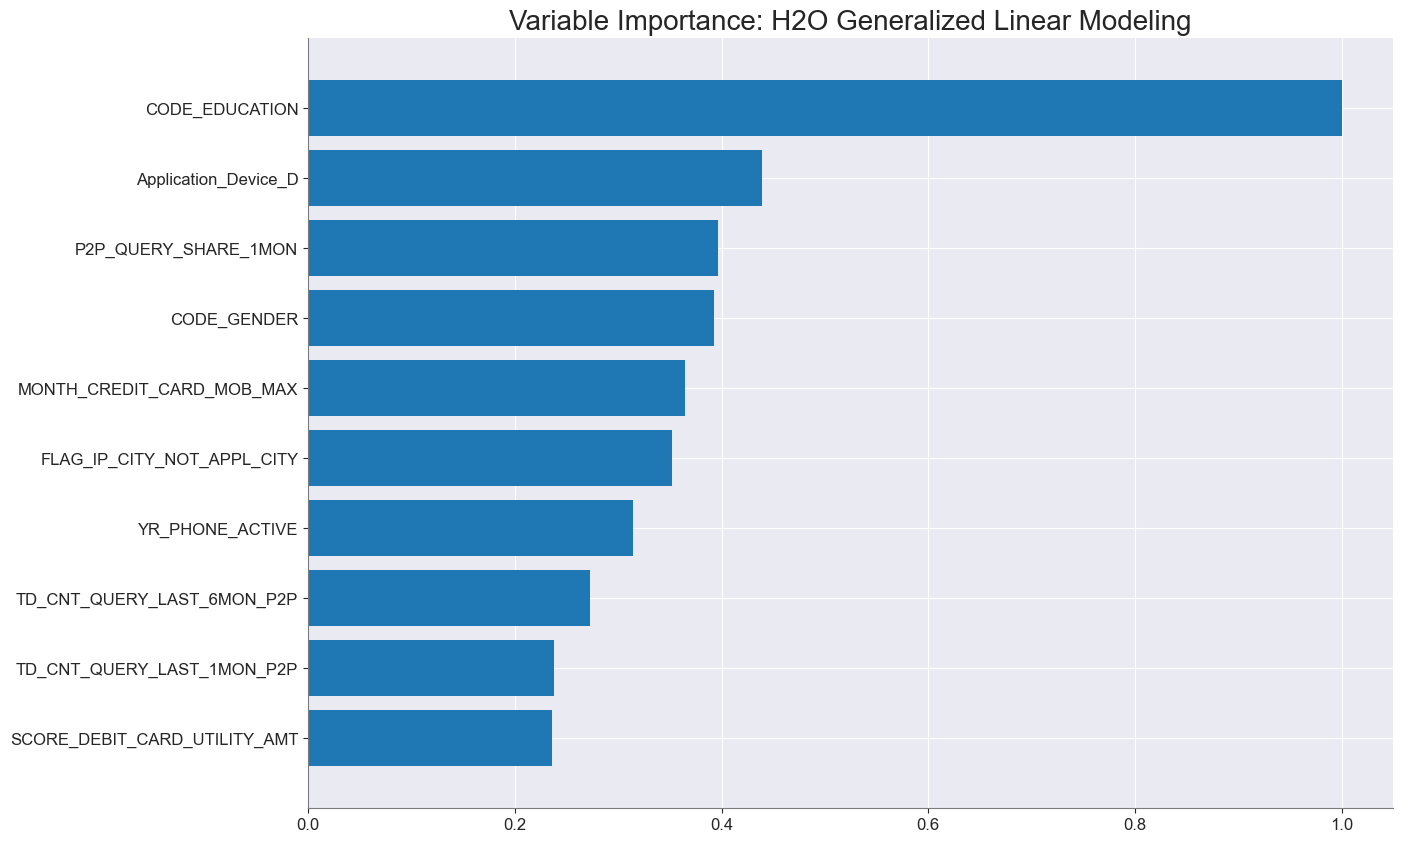

<Figure size 640x480 with 0 Axes>

In [115]:
# Show importance table in notebook
my_model.varimp(use_pandas=True)

# Or plot the feature importances (works for GBM, DRF, XRT etc.)
my_model.varimp_plot()

In [99]:
my_model = loaded_models[2]
my_model

Model Details
=============
H2OGeneralizedLinearEstimator : Generalized Linear Modeling
Model Key: GLM_1_AutoML_2_20250803_223708


GLM Model: summary
    family    link    regularization              lambda_search                                                                  number_of_predictors_total    number_of_active_predictors    number_of_iterations    training_frame
--  --------  ------  --------------------------  -----------------------------------------------------------------------------  ----------------------------  -----------------------------  ----------------------  ------------------------------------------------
    binomial  logit   Ridge ( lambda = 0.01129 )  nlambda = 30, lambda.max = 5.5255, lambda.min = 0.01129, lambda.1se = 0.07591  38                            38                             28                      AutoML_2_20250803_223708_training_py_17_sid_b5f5

ModelMetricsBinomialGLM: glm
** Reported on train data. **

MSE: 0.1476716076242648
RMSE: 0.3842806365460857
LogLoss: 0.463847358676246
AUC: 0.6716746852128835
AUCPR: 0.3158567432564321
Gini: 0.3433493704257671
Null degrees of freedom: 11999
Residual degrees of freedom: 11961
Null deviance: 11813.005962944113
Residual deviance: 11132.336608229904
AIC: 11210.336608229904

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.2012366396142364
       0     1     Error    Rate
-----  ----  ----  -------  ----------------
0      6291  3379  0.3494   (3379.0/9670.0)
1      920   1410  0.3948   (920.0/2330.0)
Total  7211  4789  0.3583   (4299.0/12000.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.201237     0.396123  227
max f2                       0.12635      0.568095  316
max f0point5                 0.257877     0.344406  168
max accuracy                 0.45897      0.805917  46
max precision                0.45897      0.50303   46
max recall                   0.0438975    1         395
max specificity              0.753518     0.999897  0
max absolute_mcc             0.201237     0.206554  227
max min_per_class_accuracy   0.194941     0.623992  234
max mean_per_class_accuracy  0.201237     0.627859  227
max tns                      0.753518     9669      0
max fns                      0.753518     2330      0
max fps                      0.0298794    9670      399
max tps                      0.0438975    2330      395
max tnr                      0.753518     0.999897  0
max fnr                      0.753518     1         0
max fpr                      0.0298794    1         399
max tpr                      0.0438975    1         395

Gains/Lift Table: Avg response rate: 19.42 %, avg score: 19.42 %
group    cumulative_data_fraction    lower_threshold    lift      cumulative_lift    response_rate    score      cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  --------  -----------------  ---------------  ---------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.01                        0.476463           2.40343   2.40343            0.466667         0.545677   0.466667                    0.545677            0.0240343       0.0240343                  140.343   140.343            0.0174159
2        0.02                        0.432              2.18884   2.29614            0.425            0.452156   0.445833                    0.498916            0.0218884       0.0459227                  118.884   129.614            0.0321689
3        0.03                        0.402497           1.80258   2.13162            0.35             0.416129   0.413889                    0.47132             0.0180258       0.0639485                  

## 8. Prediction

In [100]:
# Get predictions (returns an H2OFrame with class and probs)
preds = my_model.predict(test_hex).as_data_frame()
# View the frame
preds.head()

glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


,predict,p0,p1
0,1,0.788633,0.211367
1,1,0.790126,0.209874
2,0,0.835554,0.164446
3,0,0.911443,0.088557
4,1,0.796836,0.203164


In [101]:
# Extract the probability of class 1
best_model_probs = preds['p1']
best_model_probs.head()

0    0.211367
1    0.209874
2    0.164446
3    0.088557
4    0.203164
Name: p1, dtype: float64

In [102]:
best_model_pred = preds['predict']
best_model_pred.head()

0    1
1    1
2    0
3    0
4    1
Name: predict, dtype: int64

## 9. Evaluate Model Performance

### Accuracy

In [103]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
print('The test data:',accuracy_score(y_test,best_model_pred))

The test data: 0.6455


### Confusion Matrix

In [104]:
best_cm = pd.DataFrame(confusion_matrix(y_test,best_model_pred))
best_cm.rename(columns={0:'Predicted Negative', 1:'Predicted Positive'},
         index = {0:'Actual Negative',1:'Actual Positive'},inplace=True)
best_cm

,Predicted Negative,Predicted Positive
Actual Negative,2156,1098
Actual Positive,320,426


### AUC-ROC

In [105]:
best_roc_auc_value = roc_auc_score(y_test,best_model_probs)
best_roc_auc_value

0.6663022289745268

### Plot ROC Curve

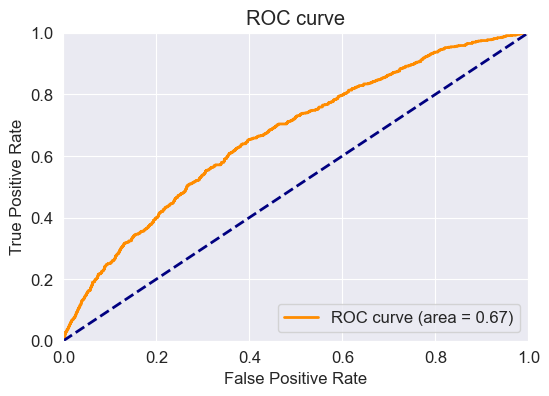

In [106]:
def plot_roc(y_true,y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = roc_auc_score(y_true,y_prob)
    lw=2
    plt.figure(figsize=(6,4))
    plt.plot(fpr,tpr, color='darkorange',lw=lw,label='ROC curve (area = %0.2f)' %roc_auc_value)
    plt.plot([0,1],[0,1], color='navy',lw=lw,linestyle='--')
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve')
    plt.legend(loc='lower right')
    plt.show()
    
plot_roc(y_test, best_model_probs)

### The Prediction-Recall Curve


   * ROC curve: The ROC curve plots the true positive rate vs. the false rositive sate

	  * The area under the curve (AUC): A value between 0.5 (random) and 1.0 (perfect), measuring the prediction accuracy

   * Recall (R) = The number of true positives / (the number of true positives + the number of false negatives)



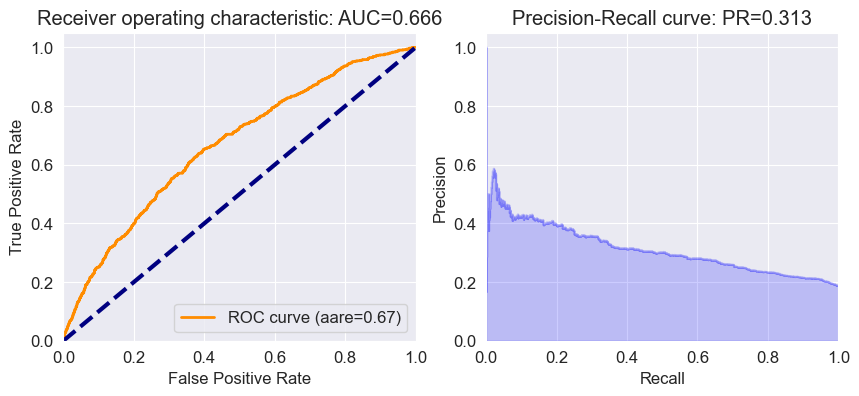

In [107]:
from sklearn.metrics import roc_curve, auc, average_precision_score, precision_recall_curve

def ROC_PR(y_actual, y_pred):
    # ROC
    fpr = list()
    tpr = list()
    roc_auc = list()
    fpr,tpr,_ = roc_curve(y_actual,y_pred)
    roc_auc = auc(fpr,tpr)
    
    # Precision-Recall
    average_precision = average_precision_score(y_actual,y_pred)

    print('')
    print('   * ROC curve: The ROC curve plots the true positive rate vs. the false rositive sate')
    print('')
    print('	  * The area under the curve (AUC): A value between 0.5 (random) and 1.0 (perfect), measuring the prediction accuracy')
    print('')
    print('   * Recall (R) = The number of true positives / (the number of true positives + the number of false negatives)')
    print('')
    
    # plotting
    plt.figure(figsize=(10,4))

    # ROC
    plt.subplot(1,2,1)
    plt.plot(fpr,tpr,color='darkorange',lw=2,label='ROC curve (aare=%0.2f)' % roc_auc)
    plt.plot([0,1],[0,1],color='navy',lw=3,linestyle='--')
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic: AUC={0:0.3f}'.format(roc_auc))
    plt.legend(loc='lower right')

    # Precision-Recall
    plt.subplot(1,2,2)
    precision,recall,_ = precision_recall_curve(y_actual,y_pred)
    plt.step(recall,precision,color='b',alpha=0.2,where='post')
    plt.fill_between(recall,precision,step='post',alpha=0.2,color='b')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.ylim([0.0,1.05])
    plt.xlim([0.0,1.0])
    plt.title('Precision-Recall curve: PR={0:0.3f}'.format(average_precision))
    plt.show()
    
ROC_PR(y_test,best_model_probs)

### The F1 Score

In [108]:
from sklearn.metrics import f1_score
# Calculate the F1 score
f1 = f1_score(y_test, best_model_pred)  # y_test is the actual, test_pred is the prediction
print("F1 Score:", f1)

F1 Score: 0.37533039647577093


### The Gains Table

In [109]:
def gains_table_profit(Y_test,y_pred):
    df_prep = pd.DataFrame(columns = ['actual','pred'])
    df_prep['actual'] = Y_test.values
    df_prep['pred'] =y_pred.values
    df_prep = df_prep.sort_values(by='pred',ascending=False)
    df_prep['row_id'] = range(0,0+len(df_prep))
    df_prep.head()

    df_prep['decile'] = (df_prep['row_id'] / (len(df_prep)/10)).astype(int)
    df_prep.loc[df_prep['decile'] == 10] =9
    df_prep['decile'].value_counts()

    # Create gains table
    gains = df_prep.groupby('decile')['actual'].agg(['count','sum'])
    gains.columns = ['count','actual']
    gains

    gains['non_actual'] = gains['count'] - gains['actual']
    gains['cum_count'] = gains['count'].cumsum()
    gains['cum_actual'] = gains['actual'].cumsum()
    gains['cum_non_actual'] = gains['non_actual'].cumsum()
    gains['percent_cum_actual'] = (gains['cum_actual'] / np.max(gains['cum_actual'])).round(2)
    gains['percent_cum_non_actual'] = (gains['cum_non_actual'] / np.max(gains['cum_non_actual'])).round(2)
    gains['if_random'] = np.max(gains['cum_actual']) /10
    gains['if_random'] = gains['if_random'].cumsum()
    gains['lift'] = (gains['cum_actual'] / gains['if_random']).round(2)
    gains['K_S'] = np.abs( gains['percent_cum_actual'] - gains['percent_cum_non_actual']  ) * 100 
    gains['gain'] = (gains['cum_actual'] / gains['cum_count']*100).round(2)
    gains['revenue'] = approved_load * irr *  gains['non_actual']
    gains['cost'] = approved_load *  gains['actual']
    gains['profit'] = gains['revenue'] - gains['cost']
    return(gains)
    
# Assume the following values
approved_load = 10000
irr = 0.10 # annual interest rate

best_gains = gains_table_profit(y_test,best_model_probs)
best_gains

,count,actual,non_actual,cum_count,cum_actual,cum_non_actual,percent_cum_actual,percent_cum_non_actual,if_random,lift,K_S,gain,revenue,cost,profit
decile,,,,,,,,,,,,,,,
0,400,157,243,400,157,243,0.21,0.07,74.6,2.10,14.0,39.25,243000.0,1570000,-1327000.0
1,400,106,294,800,263,537,0.35,0.17,149.2,1.76,18.0,32.88,294000.0,1060000,-766000.0
2,400,96,304,1200,359,841,0.48,0.26,223.8,1.60,22.0,29.92,304000.0,960000,-656000.0
3,400,89,311,1600,448,1152,0.60,0.35,298.4,1.50,25.0,28.00,311000.0,890000,-579000.0
4,400,70,330,2000,518,1482,0.69,0.46,373.0,1.39,23.0,25.90,330000.0,700000,-370000.0
5,400,53,347,2400,571,1829,0.77,0.56,447.6,1.28,21.0,23.79,347000.0,530000,-183000.0
6,400,57,343,2800,628,2172,0.84,0.67,522.2,1.20,17.0,22.43,343000.0,570000,-227000.0
7,400,56,344,3200,684,2516,0.92,0.77,596.8,1.15,15.0,21.38,344000.0,560000,-216000.0
8,400,39,361,3600,723,2877,0.97,0.88,671.4,1.08,9.0,20.08,361000.0,390000,-29000.0


### The Cumulative Life Curve

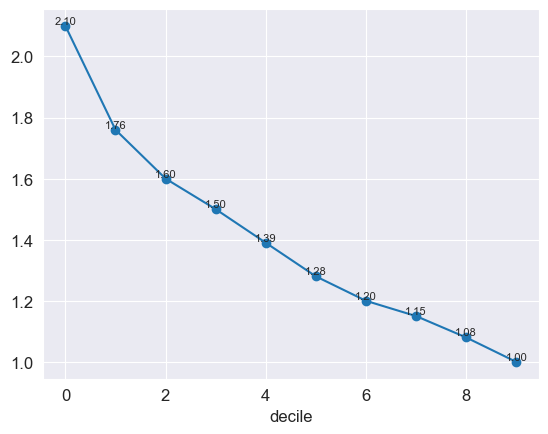

In [116]:
ax = best_gains['lift'].plot.line(marker='o')
for i, (x, y) in enumerate(zip(best_gains.index, best_gains['lift'])):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
plt.show()

### The Kolmogorov-Smirnov (K-S) statistic

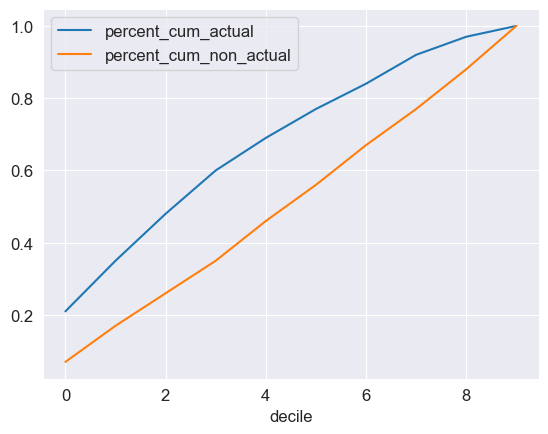

In [117]:
best_gains[['percent_cum_actual','percent_cum_non_actual']].plot.line()
plt.show()

### Model Performance Evaluation Summary

Our best model achieved an overall test accuracy of 64.6%, with an AUC-ROC of 0.67, indicating moderately strong discrimination between default and non-default cases. The F1 score of 0.38 highlights a balance between precision and recall for identifying defaulters, while the confusion matrix shows reasonable sensitivity but room for improvement in correctly identifying positives. The precision-recall curve further suggests that, although the model captures many true defaulters, there is still significant overlap between the predicted and actual default classes.

Our cumulative lift score reached **2.1** in the top decile, meaning the model can identify default cases at a rate **2.1** times higher than random selection in the most valuable segment. To achieve this, we leveraged H2O AutoML’s ensemble modeling, but went further by systematically enhancing the dataset:
- **Feature engineering:** We created new features, such as ratios of loan amount to debit card score and single card limit, measures of query intensity and growth, categorical bins for phone and device tenure, flags for risky behaviors (e.g., young/new device users), and share of P2P queries, all designed to reveal deeper borrower risk patterns.
- **Imputation:** We used advanced multivariate imputation (IterativeImputer) to fill in missing values by capturing dependencies between variables, improving data completeness and integrity.
- **Target/mean encoding:** For categorical variables, we replaced raw labels with mean-encoded values based on observed default rates, allowing the model to capture subtle effects not visible in traditional encodings.

Despite these improvements, further lift curve gains may be possible in future work by exploring additional interaction features, incorporating external credit signals, fine-tuning hyperparameters beyond AutoML defaults, or using cost-sensitive learning to better align predictions with business objectives. Continuous feature enrichment and more granular segmentation of borrower behaviors are key areas for ongoing model enhancement.

## 10. Profit & Loss Calculations (P&L)

Assumptions
- Each approved loan is worth \$10,000.
- Approved loans have an annual interest rate of 10%, generating \$1,000 in revenue per loan per year.
- If a loan defaults, the bank loses the entire loan amount (\$10,000).

Profit calculation:
- If a loan is approved and does not default, the bank gains \$1,000 in interest revenue. 
- If a loan is approved and defaults, the bank loses \$10,000.
- Calculate the overall profit or loss across the test dataset.
- Total Revenue: Sum of gains from approved loans that do not default.
- Total Loss: Sum of losses from approved loans that default.
- Net Profit: Total Revenue - Total Loss.

What we do in this section:
- We will perform the P&L for interest rate at 4%, 8%, 12% and describe if that impacts our recommendation.

In [118]:
irr = 0.04 # annual interest rate
sensitivity = gains_table_profit(y_test,best_model_probs)
selected_profit = sensitivity[sensitivity['profit']>0]['profit'].sum()
print('The profits from the positive profit deciles is:', selected_profit)
sensitivity

The profits from the positive profit deciles is: 0.0


,count,actual,non_actual,cum_count,cum_actual,cum_non_actual,percent_cum_actual,percent_cum_non_actual,if_random,lift,K_S,gain,revenue,cost,profit
decile,,,,,,,,,,,,,,,
0,400,157,243,400,157,243,0.21,0.07,74.6,2.10,14.0,39.25,97200.0,1570000,-1472800.0
1,400,106,294,800,263,537,0.35,0.17,149.2,1.76,18.0,32.88,117600.0,1060000,-942400.0
2,400,96,304,1200,359,841,0.48,0.26,223.8,1.60,22.0,29.92,121600.0,960000,-838400.0
3,400,89,311,1600,448,1152,0.60,0.35,298.4,1.50,25.0,28.00,124400.0,890000,-765600.0
4,400,70,330,2000,518,1482,0.69,0.46,373.0,1.39,23.0,25.90,132000.0,700000,-568000.0
5,400,53,347,2400,571,1829,0.77,0.56,447.6,1.28,21.0,23.79,138800.0,530000,-391200.0
6,400,57,343,2800,628,2172,0.84,0.67,522.2,1.20,17.0,22.43,137200.0,570000,-432800.0
7,400,56,344,3200,684,2516,0.92,0.77,596.8,1.15,15.0,21.38,137600.0,560000,-422400.0
8,400,39,361,3600,723,2877,0.97,0.88,671.4,1.08,9.0,20.08,144400.0,390000,-245600.0


In [119]:
irr = 0.08 # annual interest rate
sensitivity = gains_table_profit(y_test,best_model_probs)
selected_profit = sensitivity[sensitivity['profit']>0]['profit'].sum()
print('The profits from the positive profit deciles is:', selected_profit)
sensitivity

The profits from the positive profit deciles is: 71600.0


,count,actual,non_actual,cum_count,cum_actual,cum_non_actual,percent_cum_actual,percent_cum_non_actual,if_random,lift,K_S,gain,revenue,cost,profit
decile,,,,,,,,,,,,,,,
0,400,157,243,400,157,243,0.21,0.07,74.6,2.10,14.0,39.25,194400.0,1570000,-1375600.0
1,400,106,294,800,263,537,0.35,0.17,149.2,1.76,18.0,32.88,235200.0,1060000,-824800.0
2,400,96,304,1200,359,841,0.48,0.26,223.8,1.60,22.0,29.92,243200.0,960000,-716800.0
3,400,89,311,1600,448,1152,0.60,0.35,298.4,1.50,25.0,28.00,248800.0,890000,-641200.0
4,400,70,330,2000,518,1482,0.69,0.46,373.0,1.39,23.0,25.90,264000.0,700000,-436000.0
5,400,53,347,2400,571,1829,0.77,0.56,447.6,1.28,21.0,23.79,277600.0,530000,-252400.0
6,400,57,343,2800,628,2172,0.84,0.67,522.2,1.20,17.0,22.43,274400.0,570000,-295600.0
7,400,56,344,3200,684,2516,0.92,0.77,596.8,1.15,15.0,21.38,275200.0,560000,-284800.0
8,400,39,361,3600,723,2877,0.97,0.88,671.4,1.08,9.0,20.08,288800.0,390000,-101200.0


In [120]:
irr = 0.12 # annual interest rate
sensitivity = gains_table_profit(y_test,best_model_probs)
selected_profit = sensitivity[sensitivity['profit']>0]['profit'].sum()
print('The profits from the positive profit deciles is:', selected_profit)
sensitivity

The profits from the positive profit deciles is: 265600.0


,count,actual,non_actual,cum_count,cum_actual,cum_non_actual,percent_cum_actual,percent_cum_non_actual,if_random,lift,K_S,gain,revenue,cost,profit
decile,,,,,,,,,,,,,,,
0,400,157,243,400,157,243,0.21,0.07,74.6,2.10,14.0,39.25,291600.0,1570000,-1278400.0
1,400,106,294,800,263,537,0.35,0.17,149.2,1.76,18.0,32.88,352800.0,1060000,-707200.0
2,400,96,304,1200,359,841,0.48,0.26,223.8,1.60,22.0,29.92,364800.0,960000,-595200.0
3,400,89,311,1600,448,1152,0.60,0.35,298.4,1.50,25.0,28.00,373200.0,890000,-516800.0
4,400,70,330,2000,518,1482,0.69,0.46,373.0,1.39,23.0,25.90,396000.0,700000,-304000.0
5,400,53,347,2400,571,1829,0.77,0.56,447.6,1.28,21.0,23.79,416400.0,530000,-113600.0
6,400,57,343,2800,628,2172,0.84,0.67,522.2,1.20,17.0,22.43,411600.0,570000,-158400.0
7,400,56,344,3200,684,2516,0.92,0.77,596.8,1.15,15.0,21.38,412800.0,560000,-147200.0
8,400,39,361,3600,723,2877,0.97,0.88,671.4,1.08,9.0,20.08,433200.0,390000,43200.0


### Result Insights

The profit and loss (P&L) analysis demonstrates that the profitability of the loan approval strategy is highly sensitive to the chosen interest rate. At a low interest rate of 4%, the model does not yield any positive profit deciles, indicating that revenue from approved loans is not sufficient to offset default losses. When the interest rate increases to 8%, the model begins to generate positive profit in the top decile, with a modest cumulative profit of $71,600. At a 12% rate, profitability improves substantially, with a cumulative profit of $265,600 from the positive deciles. This underscores the importance of optimizing interest rates in tandem with risk modeling to achieve financial viability.


**Recommendation Impact**

These findings suggest that while our current model is able to prioritize less risky borrowers—especially at higher interest rates—it is not robust enough to consistently deliver profitability under more conservative rate scenarios. Therefore, loan approval decisions based solely on the current model and a low interest rate may expose the institution to significant financial risk. Our recommendations must account for this limitation, balancing growth objectives with prudent risk management and continuous model improvement.

**Three Recommendations**

1. Risk-Based Pricing and Tiered Lending:
Adopt a risk-based pricing strategy, setting interest rates according to borrower risk segments as identified by the model. For high-risk borrowers, increase interest rates or limit loan approval to ensure that revenue can offset expected losses. For low-risk borrowers, offer competitive rates to remain attractive while maintaining profitability.

2. Continuous Model Enhancement:
Invest in further model improvement by incorporating additional behavioral data, more sophisticated feature engineering, and external credit signals. Also, explore advanced imputation and encoding strategies, and consider regular model retraining with new data to capture changing borrower behavior and economic conditions.

3. Strengthen Lending Policies and Monitoring:
Implement stricter loan approval criteria for riskier segments as flagged by the model, and enhance post-loan monitoring to quickly identify early signs of repayment trouble. Consider combining the model’s predictions with manual review for borderline cases and providing alternative products or financial counseling to high-risk applicants.